In [1]:
from calendar import monthrange
import sqlite3
import pandas as pd
import datetime
import datetime
import seaborn as sns
from dateutil.relativedelta import relativedelta

In [2]:
connI = sqlite3.connect('Data/DB/analysis.db')

In [3]:
cursor = connI.cursor()

In [4]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print(cursor.fetchall())

[('data',), ('tmax',), ('qmax',)]


In [5]:
df = pd.read_sql("select * from data",connI)

In [6]:
df.columns

Index(['index', 'parameter', 'level', 'validDate', 'forecastDate',
       'forecastPeriod', 'window', 'point', 'observedValue', 'forecastValue',
       'difference', 'numberOfForecastValues', 'forecastStdDev'],
      dtype='object')

In [8]:
df["parameter"].value_counts()
df["level"].value_counts()


level
2 m above ground    1143744
Name: count, dtype: int64

In [33]:
df = pd.read_sql("select * from tmax",connI)

In [9]:
df.shape

(1143744, 13)

In [10]:
df.head()

,index,parameter,level,validDate,forecastDate,forecastPeriod,window,point,observedValue,forecastValue,difference,numberOfForecastValues,forecastStdDev
0,0,TMP,2 m above ground,2018-01-01,2018-02-01,1,5,p1,274.6,270.390909,4.209091,11,1.383080
1,0,TMP,2 m above ground,2018-01-01,2018-03-01,2,5,p1,276.6,273.057143,3.542857,14,2.578227
2,0,TMP,2 m above ground,2018-01-01,2018-04-01,3,5,p1,279.5,277.800000,1.700000,11,3.382011
3,0,TMP,2 m above ground,2018-01-01,2018-05-01,4,5,p1,285.6,281.091667,4.508333,12,3.653257
4,0,TMP,2 m above ground,2018-01-01,2018-06-01,5,5,p1,292.5,287.590909,4.909091,11,3.206386


In [11]:
df["validDate"].value_counts().sort_index()

validDate
2011-04-06    288
2011-04-07    288
2011-04-08    288
2011-04-09    288
2011-04-10    256
             ... 
2023-11-26     32
2023-11-27     32
2023-11-28     32
2023-11-29     32
2023-11-30     32
Name: count, Length: 4162, dtype: int64

In [12]:
df.loc[df["validDate"] == "2011-04-09"]

,index,parameter,level,validDate,forecastDate,forecastPeriod,window,point,observedValue,forecastValue,difference,numberOfForecastValues,forecastStdDev
773216,0,TMP,2 m above ground,2011-04-09,2011-05-09,1,5,p1,283.9,284.736364,0.836364,11,0.991234
773217,0,TMP,2 m above ground,2011-04-09,2011-06-09,2,5,p1,291.1,290.681818,0.418182,11,0.961060
773218,0,TMP,2 m above ground,2011-04-09,2011-07-09,3,5,p1,294.0,294.327273,0.327273,11,1.053652
773219,0,TMP,2 m above ground,2011-04-09,2011-08-09,4,5,p1,292.5,293.045455,0.545455,11,1.138739
773220,0,TMP,2 m above ground,2011-04-09,2011-09-09,5,5,p1,286.7,287.745455,1.045455,11,0.825062
...,...,...,...,...,...,...,...,...,...,...,...,...,...
773499,0,TMP,2 m above ground,2011-04-09,2011-09-09,5,5,p32,292.5,293.381818,0.881818,11,1.894634
773500,0,TMP,2 m above ground,2011-04-09,2011-10-09,6,5,p32,288.5,287.572727,0.927273,11,2.833405
773501,0,TMP,2 m above ground,2011-04-09,2011-11-09,7,5,p32,276.5,280.036364,3.536364,11,2.059258
773502,0,TMP,2 m above ground,2011-04-09,2011-12-09,8,5,p32,276.1,272.618182,3.481818,11,2.286402


In [13]:
df["forecastPeriod"].value_counts()

forecastPeriod
1    130688
2    129536
3    128960
4    127936
5    126848
6    125952
7    125408
8    124704
9    123712
Name: count, dtype: int64

In [7]:
df["validDate"].str[0:4]

0          2011
1          2011
2          2011
3          2011
4          2011
           ... 
1145179    2023
1145180    2023
1145181    2023
1145182    2023
1145183    2023
Name: validDate, Length: 1145184, dtype: object

In [8]:
hist={}
for pt in df["point"].unique():
   tmp = df.loc[df["point"] == pt]
   hist[pt]={}
  
   print(pt)
   for index,row in tmp.iterrows():
       year=row["validDate"][:4]
       mon=row["validDate"][5:7]
       period=row["forecastPeriod"]

       if period not in hist[pt]:
           hist[pt][period]={}
       
       if year not in hist[pt][period]:
           hist[pt][period][year] = {}
           
       if mon not in hist[pt][period][year]:
           hist[pt][period][year][mon]={}
           hist[pt][period][year][mon]["diffs"]=0
           hist[pt][period][year][mon]["fStdDev"]=0
           hist[pt][period][year][mon]["count"]=0
           hist[pt][period][year][mon]["forcount"]=0
       
       if "all" not in hist[pt][period]:
           hist[pt][period]["all"]={}
           hist[pt][period]["all"]["all"]={}
           hist[pt][period]["all"]["all"]["diffs"]=0
           hist[pt][period]["all"]["all"]["fStdDev"]=0
           hist[pt][period]["all"]["all"]["count"]=0
           hist[pt][period]["all"]["all"]["forcount"]=0
           
       if mon not in hist[pt][period]["all"]:
           hist[pt][period]["all"][mon]={}
           hist[pt][period]["all"][mon]["diffs"]=0
           hist[pt][period]["all"][mon]["fStdDev"]=0
           hist[pt][period]["all"][mon]["count"]=0
           hist[pt][period]["all"][mon]["forcount"]=0
      
       
       hist[pt][period][year][mon]["diffs"]+= row["difference"]
       hist[pt][period][year][mon]["fStdDev"]+= row["forecastStdDev"]
       hist[pt][period][year][mon]["count"]+=1
       hist[pt][period][year][mon]["forcount"]+=row["numberOfForecastValues"]
       

       hist[pt][period]["all"][mon]["diffs"]+= row["difference"]
       hist[pt][period]["all"][mon]["fStdDev"]+= row["forecastStdDev"]
       hist[pt][period]["all"][mon]["count"]+=1
       hist[pt][period]["all"][mon]["forcount"]+=row["numberOfForecastValues"]
       
       hist[pt][period]["all"]["all"]["diffs"]+= row["difference"]
       hist[pt][period]["all"]["all"]["fStdDev"]+= row["forecastStdDev"]
       hist[pt][period]["all"]["all"]["count"]+=1
       hist[pt][period]["all"]["all"]["forcount"]+=row["numberOfForecastValues"]
       
       
       

p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p20
p21
p22
p23
p24
p25
p26
p27
p28
p29
p30
p31
p32


In [45]:
hist["p1"][1]["all"]

{'all': {'diffs': 4952.653622488618,
  'fStdDev': 4094.478648887997,
  'count': 2456,
  'forcount': 27004},
 '01': {'diffs': 578.8250749250749,
  'fStdDev': 403.96125415477826,
  'count': 212,
  'forcount': 2499},
 '02': {'diffs': 405.2803837828839,
  'fStdDev': 337.89305513465564,
  'count': 197,
  'forcount': 2184},
 '03': {'diffs': 435.37633838383863,
  'fStdDev': 353.6622591224839,
  'count': 215,
  'forcount': 2336},
 '04': {'diffs': 395.14787878787786,
  'fStdDev': 351.1957264427689,
  'count': 202,
  'forcount': 2220},
 '05': {'diffs': 302.94848484848404,
  'fStdDev': 269.81154229466244,
  'count': 192,
  'forcount': 2093},
 '06': {'diffs': 164.51632756132733,
  'fStdDev': 152.02350610207316,
  'count': 189,
  'forcount': 1981},
 '07': {'diffs': 242.1720129870135,
  'fStdDev': 221.3229467961554,
  'count': 215,
  'forcount': 2314},
 '08': {'diffs': 386.62727272727386,
  'fStdDev': 396.19241015743677,
  'count': 216,
  'forcount': 2425},
 '09': {'diffs': 714.2554545454542,
  'fSt

In [9]:
summary={}
summary["point"]=[]
summary["period"]=[]
summary["year"]=[]
summary["month"]=[]
summary["diffs"]=[]
summary["stddev"]=[]
summary["count"]=[]
summary["forcount"]=[]




for pt,d1 in sorted(hist.items()):
    for period,d2 in sorted(d1.items()):
        for year,d3 in sorted(d2.items()):
            for month,d3 in sorted(d3.items()):
                
                forcount=d3["forcount"]
                count=d3["count"]
                diffs=d3["diffs"]/count
                fStdDev=d3["fStdDev"]/count
                
                summary["point"].append(pt)
                summary["period"].append(period)
                summary["year"].append(year)
                summary["month"].append(month)
                summary["diffs"].append(diffs)
                summary["stddev"].append(fStdDev)
                summary["count"].append(count)
                summary["forcount"].append(forcount)
                
                
                
                
                
                
                

In [10]:
anl = pd.DataFrame(summary)

In [11]:
anl

,point,period,year,month,diffs,stddev,count,forcount
0,p1,1,2011,04,1.021053,1.190486,19,209
1,p1,1,2011,05,1.170649,1.995336,14,151
2,p1,1,2011,06,1.152347,1.142806,14,98
3,p1,1,2011,07,1.152652,0.805265,24,256
4,p1,1,2011,08,1.128030,1.449814,24,264
...,...,...,...,...,...,...,...,...
45787,p9,9,all,09,4.382396,1.709080,307,3373
45788,p9,9,all,10,2.211015,1.240773,309,3391
45789,p9,9,all,11,1.252300,1.162992,328,3573
45790,p9,9,all,12,1.479597,1.793840,335,3660


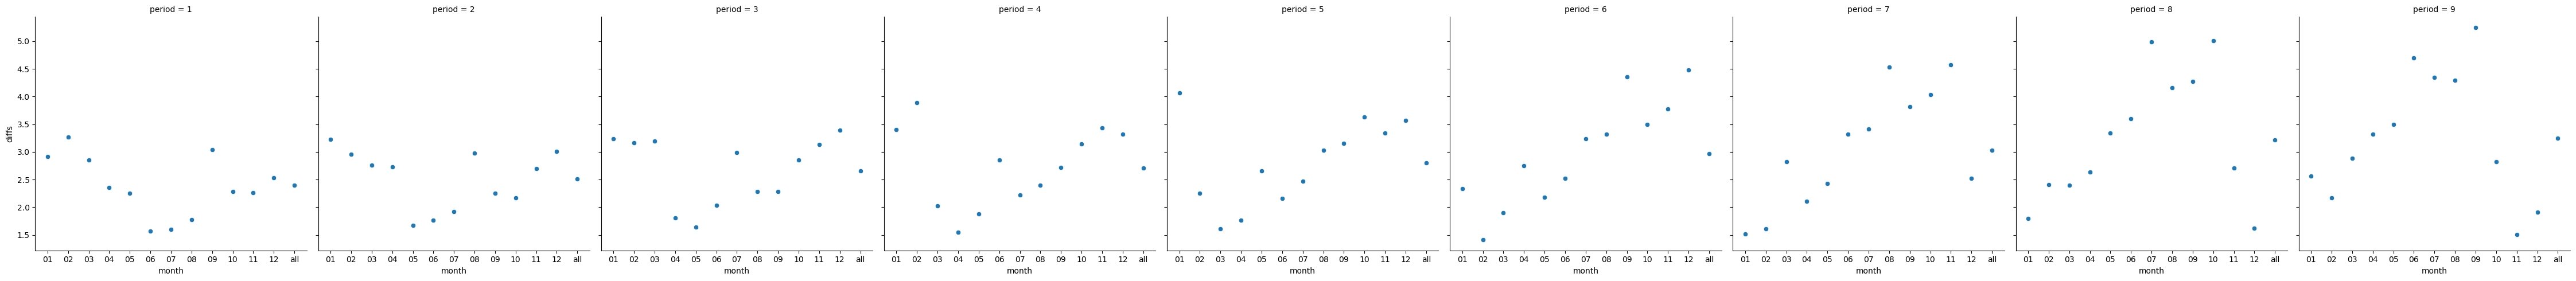

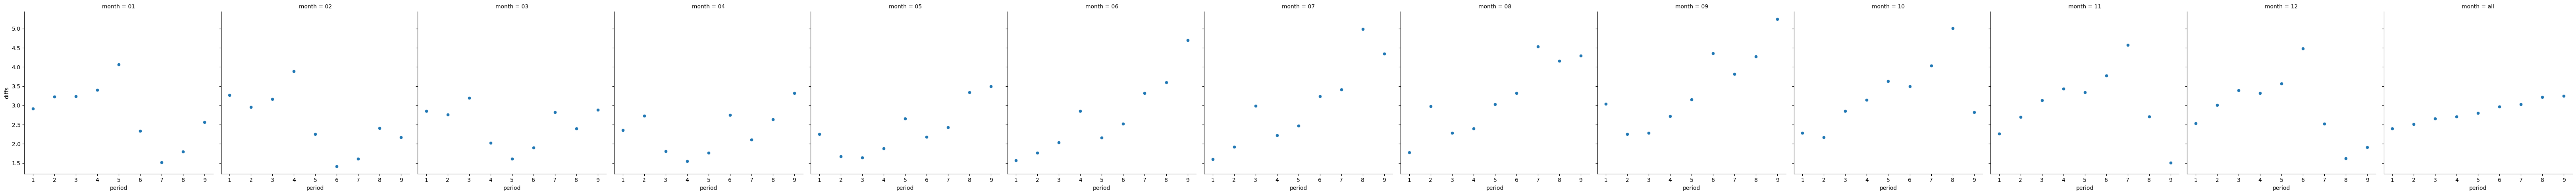

In [12]:
sns.relplot(data=anl.loc[(anl["point"] == "p23") & (anl["year"] == "all")],x="month",y="diffs",col="period")
sns.relplot(data=anl.loc[(anl["point"] == "p23") & (anl["year"] == "all")],x="period",y="diffs",col="month")


In [13]:
da = df.loc[df["forecastPeriod"] == 9]

In [14]:
da.shape

(123872, 13)

In [15]:
sdate = da["forecastDate"].min()
edate = da["forecastDate"].max()


In [16]:
da.head()

,index,parameter,level,validDate,forecastDate,forecastPeriod,window,point,observedValue,forecastValue,difference,numberOfForecastValues,forecastStdDev
8,0,TMAX,2 m above ground,2011-04-06,2012-01-06,9,5,p1,271.4,269.263636,2.136364,11,2.201487
17,0,TMAX,2 m above ground,2011-04-06,2012-01-06,9,5,p2,269.9,267.936364,1.963636,11,1.911687
26,0,TMAX,2 m above ground,2011-04-06,2012-01-06,9,5,p3,267.9,265.936364,1.963636,11,1.492831
35,0,TMAX,2 m above ground,2011-04-06,2012-01-06,9,5,p4,268.7,266.818182,1.881818,11,1.591112
44,0,TMAX,2 m above ground,2011-04-06,2012-01-06,9,5,p5,271.9,269.618182,2.281818,11,1.737135


In [17]:
b = pd.date_range(start=sdate,end=edate,freq="1D")

In [18]:
type(b)

pandas.core.indexes.datetimes.DatetimeIndex

In [19]:
a = pd.DataFrame(index=b)

In [20]:
a.head()

""
2012-01-06
2012-01-07
2012-01-08
2012-01-09
2012-01-10


In [21]:
a.reset_index(inplace=True)

In [22]:
da = da.loc[da["point"] == "p15"]

In [23]:
a.rename(columns={"index":"date"},inplace=True)

In [24]:
a.head()

,date
0,2012-01-06
1,2012-01-07
2,2012-01-08
3,2012-01-09
4,2012-01-10


In [25]:
da["forecastDate"] = pd.to_datetime(da["forecastDate"])

/tmp/ipykernel_485/1643106646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  da["forecastDate"] = pd.to_datetime(da["forecastDate"])


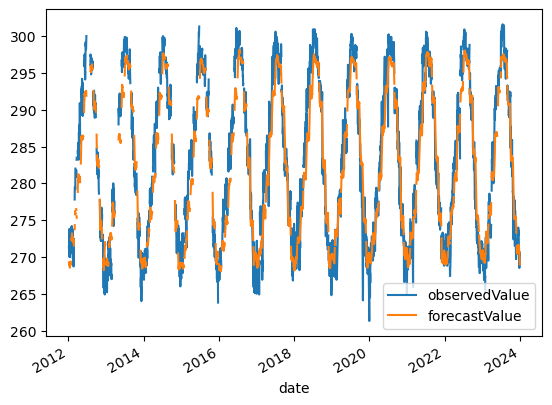

In [26]:
da = df.loc[df["forecastPeriod"] == 9]
da["forecastDate"] = pd.to_datetime(da["forecastDate"])

vrs = ["p1","p2","p3","p4","p5","p6","p7","p8","p9","p10","p11","p12","p13","p14","p15","p16","p17","p18","p19","p20","p21","p22","p23","p24","p25","p26","p27","p28","p29","p30","p31","p32"]
for pp in vrs[:1]: 
    da = da.loc[da["point"] == pp]
    b = pd.merge(a,da,left_on="date",right_on="forecastDate",how="left")
    b.sort_values(by="date",inplace=True)
    b.plot(x="date",y=["observedValue","forecastValue"])


In [46]:
b

,date,index,parameter,level,validDate,forecastDate,forecastPeriod,window,point,observedValue,forecastValue,difference,numberOfForecastValues,forecastStdDev
0,2011-05-06,0.0,TMP,2 m above ground,2011-04-06,2011-05-06,1.0,5.0,p1,285.9,284.809091,1.090909,11.0,0.966907
1,2011-05-06,0.0,TMP,2 m above ground,2011-04-06,2011-05-06,1.0,5.0,p2,283.3,282.527273,0.772727,11.0,0.913336
2,2011-05-06,0.0,TMP,2 m above ground,2011-04-06,2011-05-06,1.0,5.0,p3,280.0,279.590909,0.409091,11.0,0.926773
3,2011-05-06,0.0,TMP,2 m above ground,2011-04-06,2011-05-06,1.0,5.0,p4,280.7,280.363636,0.336364,11.0,1.001272
4,2011-05-06,0.0,TMP,2 m above ground,2011-04-06,2011-05-06,1.0,5.0,p5,283.9,283.336364,0.563636,11.0,1.112900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131272,2023-12-30,0.0,TMP,2 m above ground,2023-11-30,2023-12-30,1.0,5.0,p28,268.6,269.960000,1.360000,10.0,1.454648
131273,2023-12-30,0.0,TMP,2 m above ground,2023-11-30,2023-12-30,1.0,5.0,p29,270.9,272.460000,1.560000,10.0,1.449291
131274,2023-12-30,0.0,TMP,2 m above ground,2023-11-30,2023-12-30,1.0,5.0,p30,273.7,274.960000,1.260000,10.0,1.446989
131275,2023-12-30,0.0,TMP,2 m above ground,2023-11-30,2023-12-30,1.0,5.0,p31,275.3,276.120000,0.820000,10.0,1.387884


In [27]:
b.sort_values(by="date",inplace=True)

In [28]:
b.head()

,date,index,parameter,level,validDate,forecastDate,forecastPeriod,window,point,observedValue,forecastValue,difference,numberOfForecastValues,forecastStdDev
0,2012-01-06,0.0,TMAX,2 m above ground,2011-04-06,2012-01-06,9.0,5.0,p1,271.4,269.263636,2.136364,11.0,2.201487
1,2012-01-07,0.0,TMAX,2 m above ground,2011-04-07,2012-01-07,9.0,5.0,p1,271.1,269.181818,1.918182,11.0,2.142344
2,2012-01-08,0.0,TMAX,2 m above ground,2011-04-08,2012-01-08,9.0,5.0,p1,271.6,269.127273,2.472727,11.0,2.215442
3,2012-01-09,0.0,TMAX,2 m above ground,2011-04-09,2012-01-09,9.0,5.0,p1,271.5,268.881818,2.618182,11.0,2.109890
4,2012-01-10,0.0,TMAX,2 m above ground,2011-04-10,2012-01-10,9.0,5.0,p1,273.8,269.027273,4.772727,11.0,2.082830


<Axes: xlabel='date'>

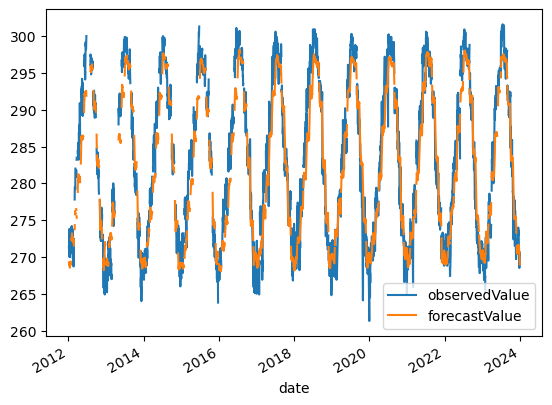

In [29]:
b.plot(x="date",y=["observedValue","forecastValue"])

In [30]:
sns.relplot(data=,x="month",y="diffs",col="period")


SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (3920049420.py, line 1)